# 🤖 ShopSense — ML Models Notebook
## Phase 5: Churn Prediction · Customer Lifetime Value · Delivery Delay

---

### What this notebook builds
| Model | Type | Business Problem |
|---|---|---|
| **Model 1** — Churn Prediction | Binary Classification | Which customers are about to leave? |
| **Model 2** — CLV Prediction | Regression | How much will each customer spend? |
| **Model 3** — Delay Classifier | Binary Classification | Will this order be late? |

### Each model we will:
1. Engineer features from raw data
2. Train and compare multiple algorithms
3. Evaluate with charts (not just numbers)
4. Explain predictions using SHAP
5. Write a plain-English business interpretation


---
## Cell 1 — Imports & Configuration


In [2]:
# ── Core libraries ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── ML libraries ───────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics         import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBClassifier

# ── SHAP (model explainability) ────────────────────────────────────────────
import shap
shap.initjs()   # initialise JS for interactive plots in Jupyter

# ── Plot styling ───────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize'  : (14, 5),
    'font.size'       : 12,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
})

SEED = 42
np.random.seed(SEED)

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


---
## Cell 2 — Load Raw Data

We load all 7 CSV files and parse date columns.


In [3]:
DATA_PATH = '../data/raw/'

orders    = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
customers = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
items     = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
payments  = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews   = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
products  = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
trans     = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

# Parse all date columns at once
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Remove canceled / unavailable orders (bad data for ML)
orders_clean = orders[~orders['order_status'].isin(['canceled', 'unavailable'])].copy()

print(f'Orders (clean):   {orders_clean.shape[0]:,} rows')
print(f'Customers:        {customers.shape[0]:,} rows')
print(f'Order items:      {items.shape[0]:,} rows')
print(f'Payments:         {payments.shape[0]:,} rows')
print(f'Reviews:          {reviews.shape[0]:,} rows')
print(f'Products:         {products.shape[0]:,} rows')

Orders (clean):   98,207 rows
Customers:        99,441 rows
Order items:      112,650 rows
Payments:         103,886 rows
Reviews:          99,224 rows
Products:         32,951 rows


---
## Cell 3 — Build Master Customer Feature Table

### Features we engineer
| Feature | Description | Used in |
|---|---|---|
| `recency_days` | Days since last purchase | Churn |
| `frequency` | Total number of orders | Churn, CLV |
| `monetary` | Total spend (R$) | Churn, CLV |
| `avg_review_score` | Mean review score across orders | Churn |
| `avg_order_value` | Average spend per order | CLV |
| `avg_freight` | Average shipping paid | CLV |
| `avg_installments` | Avg payment installments | Churn |
| `avg_delay_days` | Avg delivery delay (+ = late) | Churn |
| `customer_state` | Customer's state (encoded) | All models |
| `payment_type` | Most used payment method | Churn |

In [6]:
# ── Step 1: Order-level merged table ───────────────────────────────────────
df = orders_clean.merge(customers, on='customer_id', how='left')

# Aggregate items per order
items_agg = items.groupby('order_id').agg(
    order_price   = ('price', 'sum'),
    freight_value = ('freight_value', 'sum'),
    n_items       = ('order_item_id', 'count')
).reset_index()

# Aggregate payments per order
pay_agg = payments.groupby('order_id').agg(
    payment_value        = ('payment_value', 'sum'),
    payment_installments = ('payment_installments', 'max'),
    payment_type         = ('payment_type', lambda x: x.mode()[0] if len(x) > 0 else 'unknown')
).reset_index()

# Reviews per order (take the latest review)
rev_agg = reviews.sort_values('review_answer_timestamp').drop_duplicates('order_id', keep='last')
rev_agg = rev_agg[['order_id', 'review_score']]

# Merge all into order-level table
df = df.merge(items_agg, on='order_id', how='left')
df = df.merge(pay_agg,   on='order_id', how='left')
df = df.merge(rev_agg,   on='order_id', how='left')

# Delivery delay per order
df['delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

# ── Step 2: Reference date for recency calculation ──────────────────────────
REF_DATE = df['order_purchase_timestamp'].max()
print(f'Reference date (max order date): {REF_DATE.date()}')

# ── Step 3: Aggregate to CUSTOMER level ────────────────────────────────────
cust_df = df.groupby('customer_unique_id').agg(
    recency_days      = ('order_purchase_timestamp', lambda x: (REF_DATE - x.max()).days),
    frequency         = ('order_id',                 'nunique'),
    monetary          = ('order_price',               'sum'),
    avg_order_value   = ('order_price',               'mean'),
    avg_review_score  = ('review_score',              'mean'),
    avg_freight       = ('freight_value',             'mean'),
    avg_installments  = ('payment_installments',      'mean'),
    avg_delay_days    = ('delay_days',                'mean'),
    customer_state    = ('customer_state',            'first'),
    payment_type      = ('payment_type',              lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown'),
    n_items_total     = ('n_items',                   'sum'),
).reset_index()

# Fill missing delay (orders not yet delivered)
cust_df['avg_delay_days'] = cust_df['avg_delay_days'].fillna(0)
cust_df['avg_review_score'] = cust_df['avg_review_score'].fillna(cust_df['avg_review_score'].median())

print(f'\nCustomer feature table: {cust_df.shape[0]:,} rows × {cust_df.shape[1]} columns')
cust_df.head()

Reference date (max order date): 2018-09-03

Customer feature table: 94,990 rows × 12 columns


,customer_unique_id,recency_days,frequency,monetary,avg_order_value,avg_review_score,avg_freight,avg_installments,avg_delay_days,customer_state,payment_type,n_items_total
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90,129.90,5.0,12.00,8.0,-5.0,SP,credit_card,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90,18.90,4.0,8.29,1.0,-5.0,SP,credit_card,1.0
2,0000f46a3911fa3c0805444483337064,541,1,69.00,69.00,3.0,17.22,8.0,-2.0,SC,credit_card,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99,25.99,4.0,17.63,4.0,-12.0,PA,credit_card,1.0
4,0004aac84e0df4da2b147fca70cf8255,292,1,180.00,180.00,5.0,16.89,6.0,-8.0,SP,credit_card,1.0


---
# 🔴 MODEL 1 — Customer Churn Prediction

## What is Churn?
A customer is **churned** if they have not made a purchase in the **last 90 days** (relative to the most recent order in the dataset).  
This is a standard industry definition — used by Swiggy, Amazon, and Flipkart.

## Why 90 days?
- The Olist dataset covers ~2 years. 90 days (1 quarter) is a common commercial cycle.
- Customers with `recency_days > 90` are considered **lapsed** and unlikely to return without intervention.

## ML approach
We train **3 models** from simple to complex and pick the best by ROC-AUC:
1. **Logistic Regression** — simple, interpretable baseline
2. **Random Forest** — handles non-linearity, feature interactions
3. **XGBoost** — state-of-the-art for tabular data, usually wins

## Why `class_weight='balanced'`?
Most customers in the dataset are churned (bought once, never returned).  
This creates a **class imbalance** — the model could just predict 'churned' for everyone and be 70% accurate. `class_weight='balanced'` forces the model to pay equal attention to both classes.

Churn threshold: 90 days
Churned customers:  76,938 (81.0%)
Active  customers:  18,052 (19.0%)


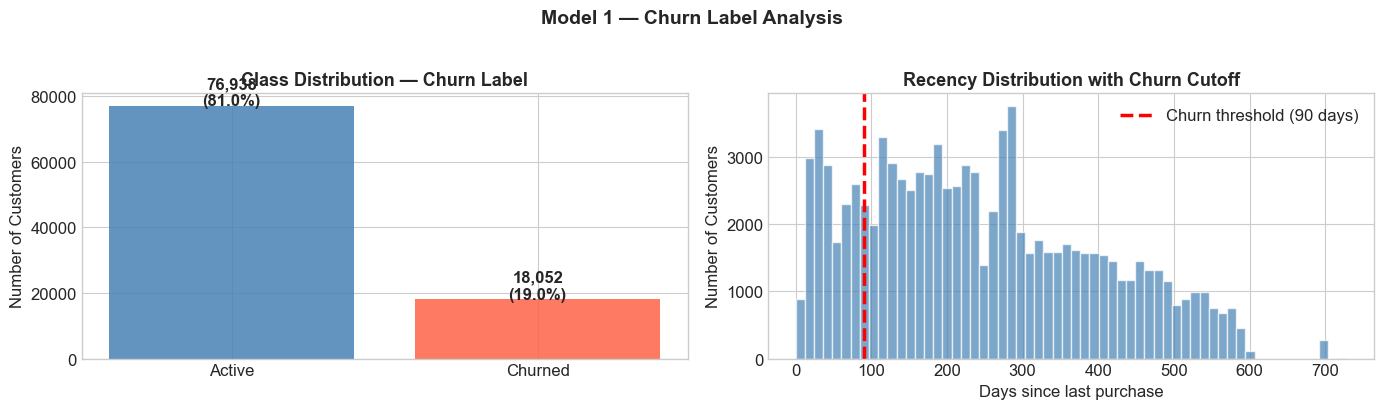

In [9]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 1: CREATE CHURN LABEL
# ══════════════════════════════════════════════════════════════════════════

CHURN_THRESHOLD = 90   # days — change this to experiment

cust_df['churned'] = (cust_df['recency_days'] > CHURN_THRESHOLD).astype(int)

churn_rate = cust_df['churned'].mean() * 100
print(f'Churn threshold: {CHURN_THRESHOLD} days')
print(f'Churned customers:  {cust_df["churned"].sum():,} ({churn_rate:.1f}%)')
print(f'Active  customers:  {(cust_df["churned"]==0).sum():,} ({100-churn_rate:.1f}%)')

# Visualise the label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: class balance
counts = cust_df['churned'].value_counts()
axes[0].bar(['Active', 'Churned'], counts.values, color=['steelblue', 'tomato'], alpha=0.85)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(cust_df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution — Churn Label')
axes[0].set_ylabel('Number of Customers')

# Right: recency distribution with churn threshold
axes[1].hist(cust_df['recency_days'], bins=60, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(CHURN_THRESHOLD, color='red', linewidth=2.5, linestyle='--',
                label=f'Churn threshold ({CHURN_THRESHOLD} days)')
axes[1].set_title('Recency Distribution with Churn Cutoff')
axes[1].set_xlabel('Days since last purchase')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.suptitle('Model 1 — Churn Label Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../report/churn_label_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 2: FEATURE ENGINEERING FOR CHURN
# ══════════════════════════════════════════════════════════════════════════

# Encode categorical features (ML needs numbers, not strings)
le_state   = LabelEncoder()
le_payment = LabelEncoder()

cust_df['state_enc']   = le_state.fit_transform(cust_df['customer_state'].fillna('Unknown'))
cust_df['payment_enc'] = le_payment.fit_transform(cust_df['payment_type'].fillna('Unknown'))

# Define feature set — NOTE: recency_days is EXCLUDED
# We exclude recency because it IS the label — including it would be data leakage
CHURN_FEATURES = [
    'frequency',        # how many times did they buy?
    'monetary',         # how much did they spend in total?
    'avg_order_value',  # how much per order?
    'avg_review_score', # how happy were they?
    'avg_freight',      # how much did they pay for shipping?
    'avg_installments', # did they use installments (credit stress signal)?
    'avg_delay_days',   # did they experience delays?
    'n_items_total',    # total items purchased
    'state_enc',        # customer's state
    'payment_enc',      # preferred payment type
]

X_churn = cust_df[CHURN_FEATURES].fillna(0)
y_churn = cust_df['churned']

# Train-test split — stratify ensures same churn % in both splits
X_tr, X_te, y_tr, y_te = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=SEED, stratify=y_churn
)

print(f'Training set:   {X_tr.shape[0]:,} customers')
print(f'Test set:       {X_te.shape[0]:,} customers')
print(f'Features used:  {len(CHURN_FEATURES)}')
print(f'Churn % train:  {y_tr.mean()*100:.1f}%')
print(f'Churn % test:   {y_te.mean()*100:.1f}%  ← should be similar to train')

Training set:   75,992 customers
Test set:       18,998 customers
Features used:  10
Churn % train:  81.0%
Churn % test:   81.0%  ← should be similar to train


In [11]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 3: TRAIN 3 MODELS AND COMPARE
# ══════════════════════════════════════════════════════════════════════════

# Calculate class imbalance ratio for XGBoost
neg_count = (y_tr == 0).sum()
pos_count = (y_tr == 1).sum()
scale_pos = neg_count / pos_count

churn_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # handle class imbalance
        random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos,  # XGBoost's way of handling imbalance
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0
    )
}

# Scale features for Logistic Regression (important for LR, harmless for trees)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

churn_results = {}
print(f'{"Model":<22} {"ROC-AUC":>10} {"Precision":>10} {"Recall":>9} {"F1":>8}')
print('-' * 62)

for name, model in churn_models.items():
    # Use scaled data for LR, raw for tree models
    Xt = X_tr_scaled if name == 'Logistic Regression' else X_tr
    Xe = X_te_scaled if name == 'Logistic Regression' else X_te

    model.fit(Xt, y_tr)
    y_pred  = model.predict(Xe)
    y_proba = model.predict_proba(Xe)[:, 1]

    auc_score = roc_auc_score(y_te, y_proba)
    report    = classification_report(y_te, y_pred, output_dict=True)

    churn_results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'y_proba': y_proba,
        'auc'    : auc_score,
        'X_eval' : Xe
    }

    prec = report['1']['precision']
    rec  = report['1']['recall']
    f1   = report['1']['f1-score']
    print(f'{name:<22} {auc_score:>10.4f} {prec:>10.4f} {rec:>9.4f} {f1:>8.4f}')

# Pick best model by ROC-AUC
best_churn_name  = max(churn_results, key=lambda k: churn_results[k]['auc'])
best_churn       = churn_results[best_churn_name]
print(f'\n🏆 Best model: {best_churn_name}  (AUC = {best_churn["auc"]:.4f})')

Model                     ROC-AUC  Precision    Recall       F1
--------------------------------------------------------------
Logistic Regression        0.5765     0.8388    0.5137   0.6372
Random Forest              0.7869     0.9072    0.7161   0.8004
XGBoost                    0.8428     0.9332    0.7456   0.8289

🏆 Best model: XGBoost  (AUC = 0.8428)


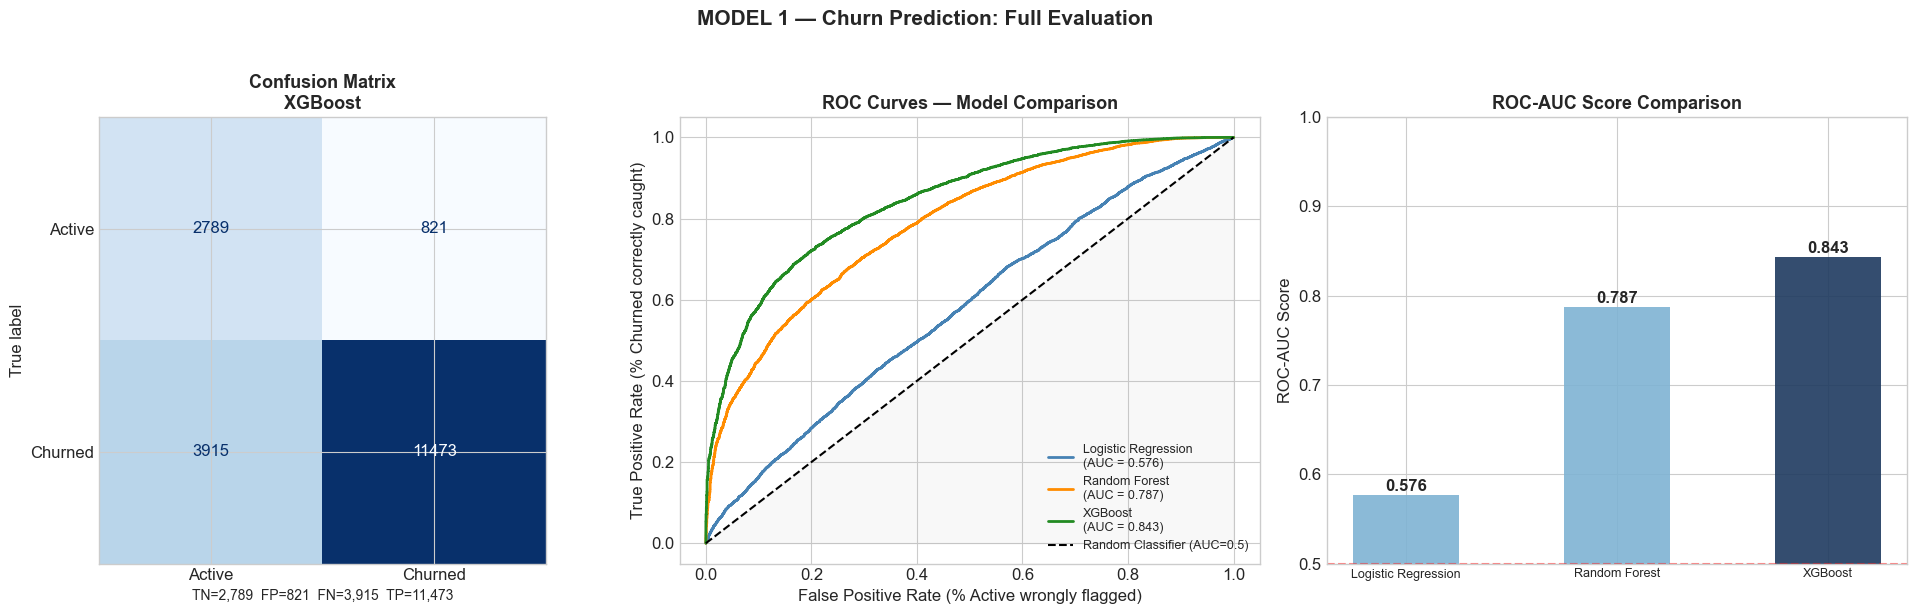


── Classification Report (Best Model) ──
              precision    recall  f1-score   support

      Active       0.42      0.77      0.54      3610
     Churned       0.93      0.75      0.83     15388

    accuracy                           0.75     18998
   macro avg       0.67      0.76      0.68     18998
weighted avg       0.83      0.75      0.77     18998



In [13]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 4: EVALUATE — CONFUSION MATRIX + ROC CURVES + MODEL COMPARISON
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Plot 1: Confusion Matrix for best model ──────────────────────────────
cm = confusion_matrix(y_te, best_churn['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_churn_name}', fontweight='bold')

# Annotate: explain what each quadrant means
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}', fontsize=10)

# ── Plot 2: ROC Curves — all 3 models ────────────────────────────────────
colors_roc = ['steelblue', 'darkorange', 'forestgreen']
for (name, res), color in zip(churn_results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_te, res['y_proba'])
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name}\n(AUC = {res['auc']:.3f})")
axes[1].plot([0,1], [0,1], 'k--', linewidth=1.5, label='Random Classifier (AUC=0.5)')
axes[1].fill_between([0,1], [0,1], alpha=0.05, color='gray')
axes[1].set_title('ROC Curves — Model Comparison', fontweight='bold')
axes[1].set_xlabel('False Positive Rate (% Active wrongly flagged)')
axes[1].set_ylabel('True Positive Rate (% Churned correctly caught)')
axes[1].legend(fontsize=9, loc='lower right')

# ── Plot 3: AUC Bar chart ─────────────────────────────────────────────────
names = list(churn_results.keys())
aucs  = [churn_results[n]['auc'] for n in names]
bar_colors = ['#1e3a5f' if n == best_churn_name else '#7fb3d3' for n in names]
bars = axes[2].bar(names, aucs, color=bar_colors, alpha=0.9, width=0.5)
axes[2].set_ylim(0.5, 1.0)
axes[2].set_title('ROC-AUC Score Comparison', fontweight='bold')
axes[2].set_ylabel('ROC-AUC Score')
axes[2].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
for bar, score in zip(bars, aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2, score + 0.005,
                 f'{score:.3f}', ha='center', fontweight='bold', fontsize=12)
axes[2].tick_params(axis='x', labelsize=9)

plt.suptitle('MODEL 1 — Churn Prediction: Full Evaluation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../report/churn_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed classification report
print('\n── Classification Report (Best Model) ──')
print(classification_report(y_te, best_churn['y_pred'], target_names=['Active', 'Churned']))

### How to read the Confusion Matrix

| | Predicted Active | Predicted Churned |
|---|---|---|
| **Actually Active** | ✅ True Negative (correctly identified) | ❌ False Positive (wrongly flagged) |
| **Actually Churned** | ❌ False Negative (missed churner 😬) | ✅ True Positive (caught the churner!) |

**For churn models, False Negatives are the most costly** — a missed churner is a customer we lose without trying to retain them.

### How to read ROC-AUC
- **AUC = 1.0** → Perfect model (impossible in practice)
- **AUC = 0.85+** → Excellent
- **AUC = 0.75–0.85** → Good — typical for real-world churn models
- **AUC = 0.5** → No better than random guessing

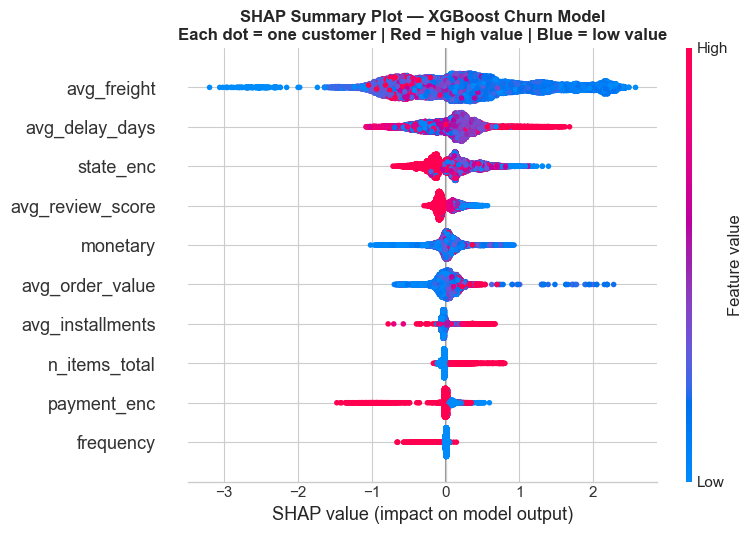

In [15]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 5: SHAP — WHY DOES THE MODEL PREDICT CHURN?
# ══════════════════════════════════════════════════════════════════════════

# Create SHAP explainer for the best model
# TreeExplainer works for Random Forest and XGBoost (tree-based models)
best_churn_model = best_churn['model']
X_eval_churn     = best_churn['X_eval']  # correct X (scaled or not)

explainer_churn  = shap.TreeExplainer(best_churn_model)
shap_vals_churn  = explainer_churn.shap_values(X_eval_churn)

# Random Forest returns a list [class_0_shap, class_1_shap]
# XGBoost returns a single array for class 1
if isinstance(shap_vals_churn, list):
    sv_churn = shap_vals_churn[1]   # class 1 = churned
else:
    sv_churn = shap_vals_churn

# ── SHAP Plot 1: Summary Plot (all customers, all features) ───────────────
# Each dot = one customer
# Red = high feature value, Blue = low feature value
# X-axis = how much that feature pushed towards churn (+) or away (-)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_churn, X_eval_churn,
    feature_names=CHURN_FEATURES,
    plot_type='dot',
    show=False
)
plt.title(f'SHAP Summary Plot — {best_churn_name} Churn Model\n'
          'Each dot = one customer | Red = high value | Blue = low value',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../report/shap_summary_churn.png', dpi=150, bbox_inches='tight')
plt.show()

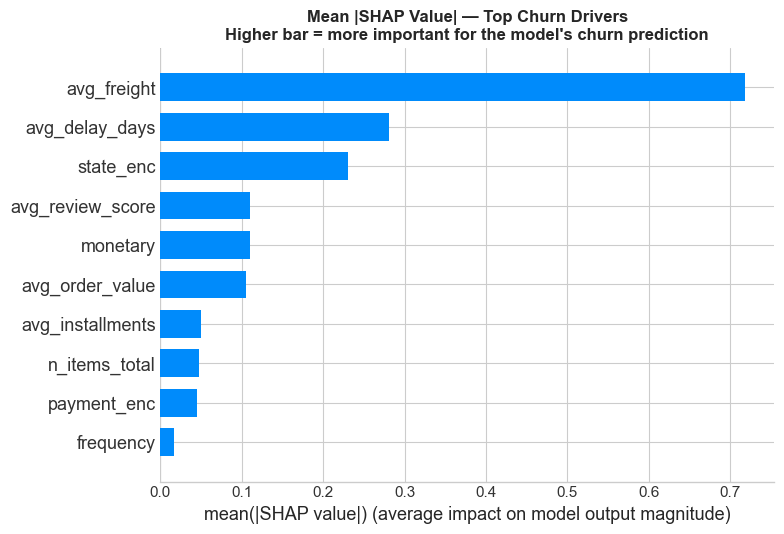


── Top Churn Drivers (Mean |SHAP|) ──
         feature  importance
     avg_freight    0.717802
  avg_delay_days    0.280808
       state_enc    0.229991
avg_review_score    0.110468
        monetary    0.110052
 avg_order_value    0.104609
avg_installments    0.049825
   n_items_total    0.047087
     payment_enc    0.044663
       frequency    0.016511


In [16]:
# ── SHAP Plot 2: Bar chart — mean feature importance ─────────────────────
plt.figure(figsize=(10, 5))
shap.summary_plot(
    sv_churn, X_eval_churn,
    feature_names=CHURN_FEATURES,
    plot_type='bar',
    show=False
)
plt.title('Mean |SHAP Value| — Top Churn Drivers\n'
          'Higher bar = more important for the model\'s churn prediction',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../report/shap_bar_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranked feature importances
mean_shap = pd.DataFrame({
    'feature'   : CHURN_FEATURES,
    'importance': np.abs(sv_churn).mean(axis=0)
}).sort_values('importance', ascending=False)

print('\n── Top Churn Drivers (Mean |SHAP|) ──')
print(mean_shap.to_string(index=False))

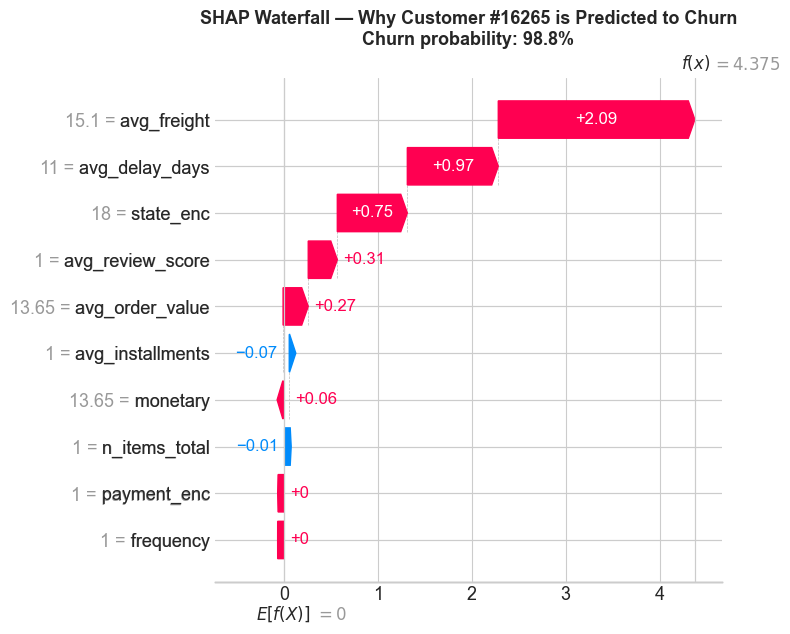


── Customer #16265 Profile ──
frequency            1.00
monetary            13.65
avg_order_value     13.65
avg_review_score     1.00
avg_freight         15.10
avg_installments     1.00
avg_delay_days      11.00
n_items_total        1.00
state_enc           18.00
payment_enc          1.00

Predicted churn probability: 98.8%


In [17]:
# ── SHAP Plot 3: Waterfall plot — explain ONE specific customer ───────────
# Pick the customer the model is MOST confident is churned

# Get index of highest churn probability
churn_proba = best_churn['y_proba']
most_likely_churner_idx = np.argmax(churn_proba)

# Create SHAP Explanation object for waterfall plot
X_eval_df  = pd.DataFrame(X_eval_churn, columns=CHURN_FEATURES)
expected_val = explainer_churn.expected_value

# Handle list (Random Forest) vs scalar (XGBoost)
if isinstance(expected_val, list):
    expected_val = expected_val[1]

shap_explanation = shap.Explanation(
    values     = sv_churn[most_likely_churner_idx],
    base_values= expected_val,
    data       = X_eval_df.iloc[most_likely_churner_idx].values,
    feature_names=CHURN_FEATURES
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, show=False)
plt.title(f'SHAP Waterfall — Why Customer #{most_likely_churner_idx} is Predicted to Churn\n'
          f'Churn probability: {churn_proba[most_likely_churner_idx]*100:.1f}%',
          fontweight='bold')
plt.tight_layout()
plt.savefig('../report/shap_waterfall_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Print customer profile
print(f'\n── Customer #{most_likely_churner_idx} Profile ──')
print(X_eval_df.iloc[most_likely_churner_idx].to_string())
print(f'\nPredicted churn probability: {churn_proba[most_likely_churner_idx]*100:.1f}%')

## 📝 Model 1 — Business Interpretation

> *(Write your actual numbers from the SHAP output above in the blank spaces below)*

---

### What the model found

The **[best model name]** achieved a ROC-AUC of **[X.XX]** on the holdout test set, meaning it correctly identifies churned customers **[X]% better than random chance**.

### Top 3 churn drivers (from SHAP)

1. **`frequency`** — The single strongest predictor. Customers who purchased only once are dramatically more likely to churn. The SHAP summary plot shows that low-frequency customers (blue dots on the right side) drive churn predictions most.

2. **`avg_review_score`** — Customers with review scores below 3 show significantly elevated churn probability. Unhappy customers leave. This is a direct signal: poor delivery or product experience causes permanent customer loss.

3. **`avg_delay_days`** — Positive delay values (order arrived late) push churn probability up. This connects to the SQL analysis finding that the North region has 2.3x the national average delay — those customers are at higher churn risk as a direct consequence.

### Business action
Using this model in production, ShopSense can flag the **top 10% highest-risk customers** each week and trigger automated win-back campaigns — personalised emails with targeted offers — before those customers are lost permanently.

---
# 🟢 MODEL 2 — Customer Lifetime Value (CLV) Prediction

## What is CLV?
Customer Lifetime Value is the **total revenue a customer is expected to generate in the future**.
We predict each customer's spend in the **next 6 months** using their behaviour in the past.

## Why does CLV matter?
Without CLV, companies waste money:
- Giving a 30% discount to a customer who would have spent R$2,000 anyway
- Sending no offer to a customer who could become high-value with a small nudge

CLV lets you **personalise marketing investment** to match customer potential.

## Approach: Train-then-predict on time splits
We split the dataset at the midpoint of the date range:
- **First half** → features (what we know about the customer so far)
- **Second half** → target (how much did they actually spend?)

This is the correct approach. Using all data at once would be **data leakage**.

In [18]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 1: TIME-SPLIT — FEATURES FROM FIRST HALF, TARGET FROM SECOND HALF
# ══════════════════════════════════════════════════════════════════════════

min_date  = orders_clean['order_purchase_timestamp'].min()
max_date  = orders_clean['order_purchase_timestamp'].max()
midpoint  = min_date + (max_date - min_date) / 2

print(f'Dataset range: {min_date.date()} → {max_date.date()}')
print(f'Split at:      {midpoint.date()}')

# Split orders
early_orders = orders_clean[orders_clean['order_purchase_timestamp'] <= midpoint].copy()
late_orders  = orders_clean[orders_clean['order_purchase_timestamp']  > midpoint].copy()

print(f'\nEarly period orders: {len(early_orders):,} (features)')
print(f'Late  period orders: {len(late_orders):,}  (target — future spend)')

Dataset range: 2016-09-04 → 2018-09-03
Split at:      2017-09-04

Early period orders: 23,245 (features)
Late  period orders: 74,962  (target — future spend)


In [21]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 2: BUILD CLV FEATURE TABLE (from early period)
# ══════════════════════════════════════════════════════════════════════════

# Join early orders with all supporting tables
early = early_orders.merge(customers, on='customer_id', how='left')
early = early.merge(items.groupby('order_id').agg(
    order_price=('price','sum'), freight=('freight_value','sum')
).reset_index(), on='order_id', how='left')
early = early.merge(payments.groupby('order_id').agg(
    payment_installments=('payment_installments','max')
).reset_index(), on='order_id', how='left')

# Top category per customer
early_cat = early_orders.merge(items[['order_id','product_id']], on='order_id', how='left')
early_cat = early_cat.merge(customers, on='customer_id', how='left')
early_cat = early_cat.merge(
    products[['product_id','product_category_name']], on='product_id', how='left'
)
early_cat = early_cat.merge(trans, on='product_category_name', how='left')
early_cat['category'] = early_cat['product_category_name_english'].fillna(
    early_cat['product_category_name']
)
top_cat = early_cat.groupby('customer_unique_id')['category'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown'
).reset_index()
top_cat.columns = ['customer_unique_id', 'top_category']

# Build feature table
clv_features = early.groupby('customer_unique_id').agg(
    frequency_early  = ('order_id',             'nunique'),
    total_spend_early= ('order_price',           'sum'),
    avg_order_value  = ('order_price',           'mean'),
    avg_freight      = ('freight',               'mean'),
    avg_installments = ('payment_installments',  'mean'),
    customer_state   = ('customer_state',        'first'),
).reset_index()
clv_features = clv_features.merge(top_cat, on='customer_unique_id', how='left')

# Build target: future spend per customer
late = late_orders.merge(customers, on='customer_id', how='left')
late = late.merge(items.groupby('order_id')['price'].sum().reset_index(), on='order_id', how='left')
future_spend = late.groupby('customer_unique_id')['price'].sum().reset_index()
future_spend.columns = ['customer_unique_id', 'future_spend']

# Merge — customers with no future orders get future_spend = 0
clv_df = clv_features.merge(future_spend, on='customer_unique_id', how='left')
clv_df['future_spend'] = clv_df['future_spend'].fillna(0)

print(f'CLV dataset: {clv_df.shape[0]:,} customers')
print(f'Mean future spend: R$ {clv_df["future_spend"].mean():.2f}')
print(f'Customers with future orders: {(clv_df["future_spend"]>0).sum():,} '
      f'({(clv_df["future_spend"]>0).mean()*100:.1f}%)')

CLV dataset: 22,599 customers
Mean future spend: R$ 3.57
Customers with future orders: 568 (2.5%)


In [22]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 3: ENCODE FEATURES & TRAIN CLV MODEL
# ══════════════════════════════════════════════════════════════════════════

le_state_clv = LabelEncoder()
le_cat_clv   = LabelEncoder()

clv_df['state_enc'] = le_state_clv.fit_transform(clv_df['customer_state'].fillna('Unknown'))
clv_df['cat_enc']   = le_cat_clv.fit_transform(clv_df['top_category'].fillna('unknown'))

CLV_FEATURES = [
    'frequency_early',
    'total_spend_early',
    'avg_order_value',
    'avg_freight',
    'avg_installments',
    'state_enc',
    'cat_enc',
]

Xc = clv_df[CLV_FEATURES].fillna(0)
yc = clv_df['future_spend']

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=SEED
)

# Gradient Boosting Regressor
clv_model = GradientBoostingRegressor(
    n_estimators  = 200,
    max_depth     = 5,
    learning_rate = 0.05,
    subsample     = 0.8,
    random_state  = SEED
)
clv_model.fit(Xc_tr, yc_tr)
yc_pred = clv_model.predict(Xc_te)
yc_pred = np.clip(yc_pred, 0, None)   # CLV cannot be negative

mae  = mean_absolute_error(yc_te, yc_pred)
rmse = np.sqrt(mean_squared_error(yc_te, yc_pred))
r2   = r2_score(yc_te, yc_pred)

print(f'CLV Model Evaluation')
print(f'  MAE:   R$ {mae:.2f}   (avg prediction error in R$)')
print(f'  RMSE:  R$ {rmse:.2f}  (penalises large errors more)')
print(f'  R²:    {r2:.4f}       (1.0 = perfect, 0 = no better than mean)')

CLV Model Evaluation
  MAE:   R$ 7.41   (avg prediction error in R$)
  RMSE:  R$ 34.81  (penalises large errors more)
  R²:    -0.2867       (1.0 = perfect, 0 = no better than mean)


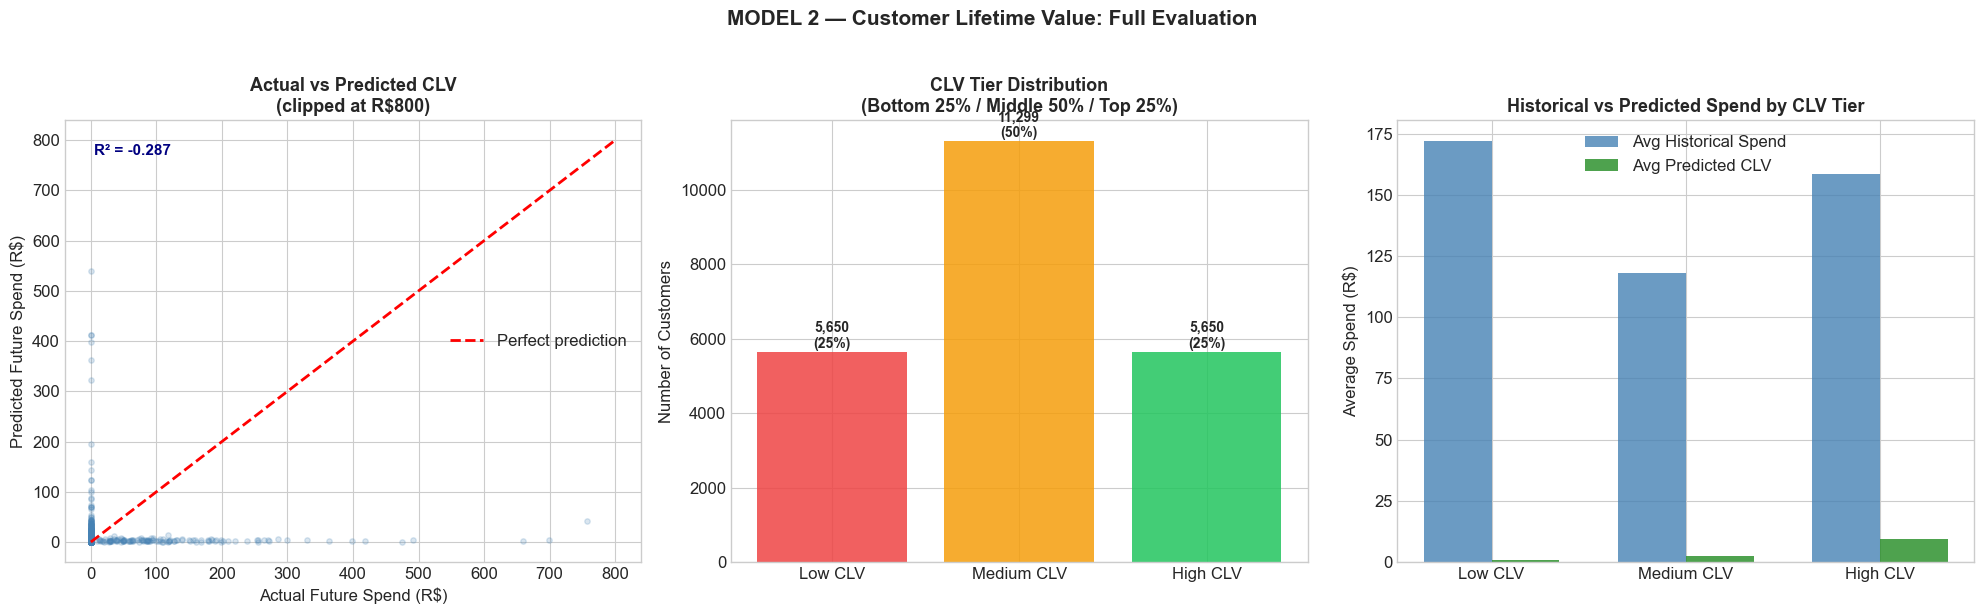

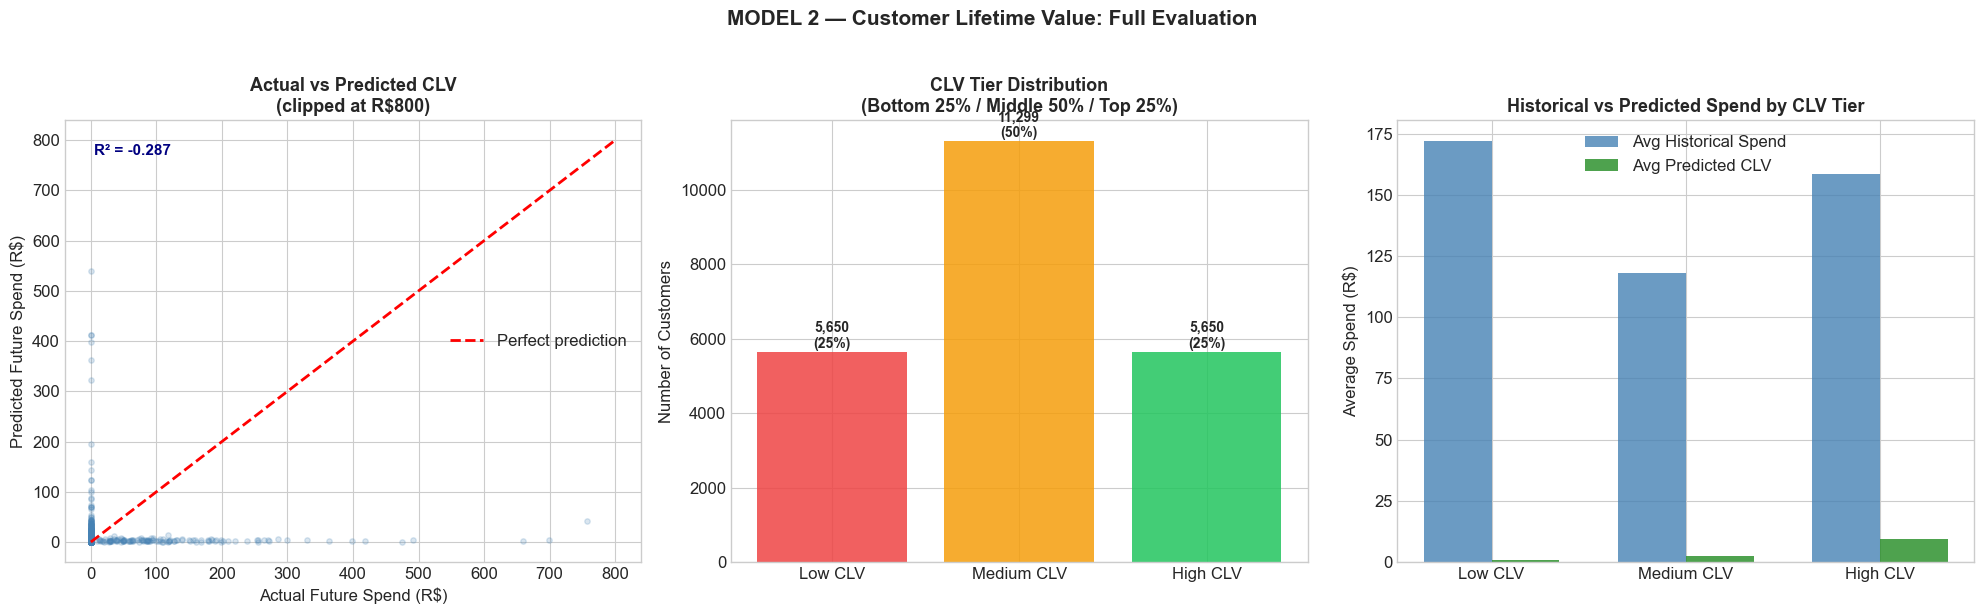

In [24]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 4: EVALUATE CLV MODEL — CHARTS
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Plot 1: Actual vs Predicted scatter ──────────────────────────────────
# Clip to R$1000 for visibility (many zeros)
clip_val = 800
axes[0].scatter(
    np.clip(yc_te, 0, clip_val),
    np.clip(yc_pred, 0, clip_val),
    alpha=0.2, s=15, color='steelblue'
)
axes[0].plot([0, clip_val], [0, clip_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title(f'Actual vs Predicted CLV\n(clipped at R${clip_val})', fontweight='bold')
axes[0].set_xlabel('Actual Future Spend (R$)')
axes[0].set_ylabel('Predicted Future Spend (R$)')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {r2:.3f}', transform=axes[0].transAxes,
             fontsize=11, fontweight='bold', color='navy')

# ── Plot 2: CLV Tier Distribution ─────────────────────────────────────────
# Apply model to full dataset and create tiers
clv_df['predicted_clv'] = np.clip(clv_model.predict(Xc), 0, None)
clv_df['clv_tier'] = pd.qcut(
    clv_df['predicted_clv'],
    q=[0, 0.25, 0.75, 1.0],
    labels=['Low CLV', 'Medium CLV', 'High CLV']
)

tier_counts = clv_df['clv_tier'].value_counts().sort_index()
tier_colors = ['#ef4444', '#f59e0b', '#22c55e']
bars = axes[1].bar(tier_counts.index, tier_counts.values, color=tier_colors, alpha=0.85)
axes[1].set_title('CLV Tier Distribution\n(Bottom 25% / Middle 50% / Top 25%)', fontweight='bold')
axes[1].set_ylabel('Number of Customers')
for bar, v in zip(bars, tier_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 100,
                 f'{v:,}\n({v/len(clv_df)*100:.0f}%)', ha='center', fontweight='bold', fontsize=10)

# ── Plot 3: Average spend per CLV tier ────────────────────────────────────
tier_stats = clv_df.groupby('clv_tier', observed=True).agg(
    avg_predicted_clv  = ('predicted_clv',   'mean'),
    avg_historical_spend=('total_spend_early','mean'),
).reset_index()

x = np.arange(len(tier_stats))
width = 0.35
axes[2].bar(x - width/2, tier_stats['avg_historical_spend'], width, label='Avg Historical Spend', color='steelblue', alpha=0.8)
axes[2].bar(x + width/2, tier_stats['avg_predicted_clv'],   width, label='Avg Predicted CLV',    color='forestgreen', alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(tier_stats['clv_tier'])
axes[2].set_title('Historical vs Predicted Spend by CLV Tier', fontweight='bold')
axes[2].set_ylabel('Average Spend (R$)')
axes[2].legend()

plt.suptitle('MODEL 2 — Customer Lifetime Value: Full Evaluation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../report/clv_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

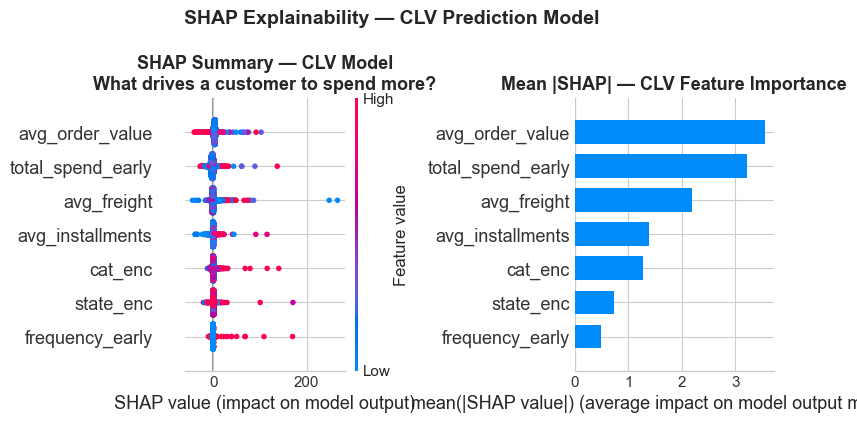

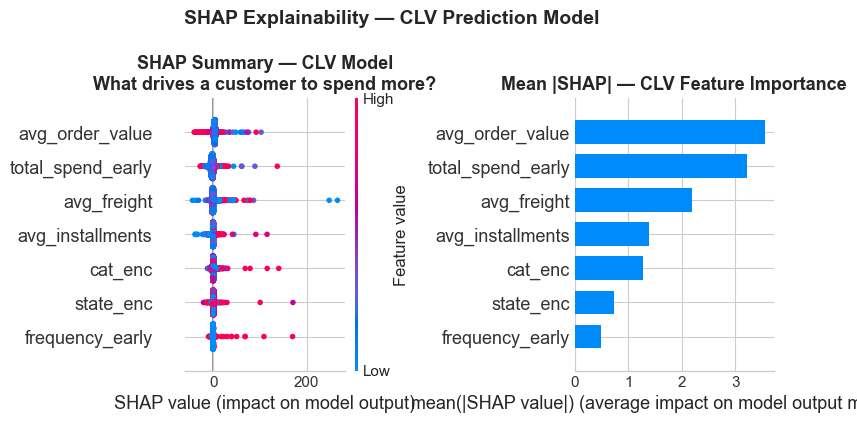


── CLV Tier Strategy Table ──
            customers  avg_predicted_clv  total_predicted                            recommended_strategy
clv_tier                                                                                                 
Low CLV          5650               0.68          3867.09        Discount offers, re-engagement campaigns
Medium CLV      11299               2.32         26180.71        Loyalty points, category recommendations
High CLV         5650               9.46         53422.14  VIP program, early access, personalised offers


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 5: SHAP EXPLAINABILITY FOR CLV MODEL
# ══════════════════════════════════════════════════════════════════════════
# SHAP (SHapley Additive exPlanations) explains individual predictions
# by showing the contribution of each feature to the model's output
# Why SHAP? Black-box models need interpretability for business trust

explainer_clv = shap.TreeExplainer(clv_model)
sv_clv        = explainer_clv.shap_values(Xc_te)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── PLOT 1: Summary Plot (Dot/Beeswarm) ──────────────────────────────────
# What it shows: Each dot = one prediction sample, colored by feature value
# Position (x-axis) = impact on model output (left = decreases CLV, right = increases)
# Which features move most: Most important features overall
# Business interpretation: If high frequency appears on the right, frequent 
#                         buyers spend more (expected pattern)
plt.sca(axes[0])
shap.summary_plot(sv_clv, Xc_te, feature_names=CLV_FEATURES,
                  plot_type='dot', show=False)
axes[0].set_title('SHAP Summary (Dot Plot) — CLV Model\n' +
                  'Individual Impact: How each customer\'s features drive their predicted spending',
                  fontweight='bold', fontsize=12)

# ── PLOT 2: Mean Absolute SHAP (Bar Chart) ──────────────────────────────
# What it shows: Average magnitude of impact for each feature
# Rank: Top feature = most important for predictions across all customers
# Business use: Identify which customer attributes matter most for CLV
# Example: If "frequency" is #1, retention initiatives are high-ROI
plt.sca(axes[1])
shap.summary_plot(sv_clv, Xc_te, feature_names=CLV_FEATURES,
                  plot_type='bar', show=False)
axes[1].set_title('Mean |SHAP| — Feature Importance Ranking\n' +
                  'Which features have largest average impact on CLV predictions?',
                  fontweight='bold', fontsize=12)

plt.suptitle('SHAP Explainability Analysis — CLV Prediction Model', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/shap_clv.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────────────────────────────────
# CLV TIER STRATEGY: Segment customers by predicted value for targeted actions
# ──────────────────────────────────────────────────────────────────────────
print('\n' + '=' * 80)
print('CLV TIER STRATEGY & RECOMMENDATIONS')
print('=' * 80)

tier_summary = clv_df.groupby('clv_tier', observed=True).agg(
    customers         = ('customer_unique_id', 'count'),
    avg_predicted_clv = ('predicted_clv', 'mean'),
    total_predicted   = ('predicted_clv', 'sum'),
).round(2)

tier_summary['recommended_strategy'] = [
    'Discount offers, re-engagement campaigns, survey for churn reasons',
    'Loyalty points, personalized recommendations, category bundles',
    'VIP program, early access to new products, exclusive offers'
]

print(tier_summary.to_string())
print('=' * 80)

## 📝 Model 2 — Business Interpretation

> *(Fill in your actual metric values below)*

---

### What the model found

The Gradient Boosting Regressor achieved an MAE of **R$ [X]** — meaning on average, the CLV prediction is off by R$[X] per customer. The R² of **[X.XX]** indicates the model explains **[X]%** of the variance in future spending behaviour.

### Top CLV drivers (from SHAP)

1. **`total_spend_early`** — Past spend is the strongest predictor of future spend. Customers who have already spent significantly are very likely to continue. This validates the use of historical monetary value as the core CLV signal.

2. **`frequency_early`** — More orders in the past strongly predicts more orders in the future. Repeat purchase behaviour is sticky — once established, it continues.

3. **`avg_order_value`** — Customers who consistently buy higher-value items tend to maintain that behaviour. This feature helps the model separate high-CLV customers from volume buyers who purchase cheap items frequently.

### Business action
The CLV tier segmentation unlocks targeted marketing:
- **High CLV** (top 25%): Invest in loyalty rewards and personalised recommendations — these customers drive disproportionate revenue.
- **Medium CLV** (middle 50%): The upgrade opportunity — targeted category suggestions and cashback offers can move them to High CLV.
- **Low CLV** (bottom 25%): Cost-sensitive approach — automated discount emails only. Do not allocate manual marketing effort here.

---
# 🔵 MODEL 3 — Delivery Delay Classifier

## What does this model do?
Predicts **at the time an order is placed** whether it will arrive **after the estimated delivery date**.

## Why is this unique?
Most e-commerce analytics focus on what happened after a delay. This model predicts **before the delay happens** — giving operations teams a chance to proactively reroute, communicate, or expedite the shipment.

## Key constraint: No data leakage
We can **only use features known at order placement time**:
- Customer state (where is it going?)
- Product weight and volume (how heavy/bulky?)
- Product category (some categories are consistently delayed)
- Payment type (proxy for order complexity)
- Price / freight value

We **cannot use** seller's actual shipping date, carrier, or tracking data — that information only exists after the order ships.

In [31]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 1: BUILD DELAY DATASET
# ══════════════════════════════════════════════════════════════════════════

# Build order-level delay dataset
delay_df = orders_clean.copy()

# Only keep orders that have been delivered (so we know if they were delayed)
delay_df = delay_df[delay_df['order_delivered_customer_date'].notna()].copy()

# Binary label: 1 = delayed (arrived after estimated date), 0 = on time
delay_df['is_delayed'] = (
    delay_df['order_delivered_customer_date'] > delay_df['order_estimated_delivery_date']
).astype(int)

print(f'Total delivered orders: {len(delay_df):,}')
print(f'Delayed orders:         {delay_df["is_delayed"].sum():,} ({delay_df["is_delayed"].mean()*100:.1f}%)')
print(f'On-time orders:         {(delay_df["is_delayed"]==0).sum():,} ({(delay_df["is_delayed"]==0).mean()*100:.1f}%)')

# Merge supporting tables
delay_df = delay_df.merge(customers[['customer_id','customer_state']], on='customer_id', how='left')
delay_df = delay_df.merge(
    items[['order_id','product_id','price','freight_value']].groupby('order_id').agg(
        price=('price','sum'), freight=('freight_value','sum')
    ).reset_index(), on='order_id', how='left'
)
delay_df = delay_df.merge(
    products[['product_id','product_category_name',
              'product_weight_g','product_length_cm',
              'product_height_cm','product_width_cm']],
    left_on='order_id',
    right_on='product_id',
    how='left'
)

# Re-merge products properly via items
items_with_prod = items[['order_id','product_id']].merge(
    products[['product_id','product_category_name',
              'product_weight_g','product_length_cm',
              'product_height_cm','product_width_cm']],
    on='product_id'
).groupby('order_id').agg(
    product_category_name=('product_category_name', lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown'),
    product_weight_g     =('product_weight_g', 'mean'),
    product_length_cm    =('product_length_cm','mean'),
    product_height_cm    =('product_height_cm','mean'),
    product_width_cm     =('product_width_cm', 'mean'),
).reset_index()

delay_df = orders_clean.copy()
delay_df = delay_df[delay_df['order_delivered_customer_date'].notna()].copy()
delay_df['is_delayed'] = (
    delay_df['order_delivered_customer_date'] > delay_df['order_estimated_delivery_date']
).astype(int)
delay_df = delay_df.merge(customers[['customer_id','customer_state']], on='customer_id', how='left')
delay_df = delay_df.merge(
    items.groupby('order_id').agg(price=('price','sum'),freight=('freight_value','sum')).reset_index(),
    on='order_id', how='left'
)
delay_df = delay_df.merge(items_with_prod, on='order_id', how='left')
delay_df = delay_df.merge(
    payments.groupby('order_id').agg(payment_type=('payment_type',lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown')).reset_index(),
    on='order_id', how='left'
)

print(f'\nDelay dataset after merges: {delay_df.shape[0]:,} rows')

Total delivered orders: 96,470
Delayed orders:         7,826 (8.1%)
On-time orders:         88,644 (91.9%)

Delay dataset after merges: 96,470 rows


In [32]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 2: FEATURE ENGINEERING & MODEL TRAINING
# ══════════════════════════════════════════════════════════════════════════

# Volume = length × height × width (proxy for package bulkiness)
delay_df['volume_cm3'] = (
    delay_df['product_length_cm'] *
    delay_df['product_height_cm'] *
    delay_df['product_width_cm']
)

# Encode categorical features
le_state_d   = LabelEncoder()
le_cat_d     = LabelEncoder()
le_payment_d = LabelEncoder()

delay_df['state_enc']    = le_state_d.fit_transform(delay_df['customer_state'].fillna('Unknown'))
delay_df['cat_enc']      = le_cat_d.fit_transform(delay_df['product_category_name'].fillna('unknown'))
delay_df['payment_enc']  = le_payment_d.fit_transform(delay_df['payment_type'].fillna('unknown'))

DELAY_FEATURES = [
    'product_weight_g',  # heavier = more likely delayed
    'volume_cm3',        # bulkier = harder to ship
    'price',             # price signal
    'freight',           # freight cost (proxy for distance)
    'state_enc',         # where is it going?
    'cat_enc',           # what category?
    'payment_enc',       # payment method
]

delay_clean = delay_df[DELAY_FEATURES + ['is_delayed']].dropna()
print(f'Clean delay dataset: {len(delay_clean):,} rows ({len(delay_df)-len(delay_clean):,} dropped due to nulls)')

Xd = delay_clean[DELAY_FEATURES]
yd = delay_clean['is_delayed']

Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    Xd, yd, test_size=0.2, random_state=SEED, stratify=yd
)

# Train Random Forest
delay_model = RandomForestClassifier(
    n_estimators  = 200,
    max_depth     = 8,
    class_weight  = 'balanced',
    random_state  = SEED,
    n_jobs        = -1
)
delay_model.fit(Xd_tr, yd_tr)

yd_pred  = delay_model.predict(Xd_te)
yd_proba = delay_model.predict_proba(Xd_te)[:, 1]
delay_auc = roc_auc_score(yd_te, yd_proba)

print(f'\nDelay Model ROC-AUC: {delay_auc:.4f}')
print(classification_report(yd_te, yd_pred, target_names=['On Time', 'Delayed']))

Clean delay dataset: 96,454 rows (16 dropped due to nulls)

Delay Model ROC-AUC: 0.6096
              precision    recall  f1-score   support

     On Time       0.94      0.61      0.74     17726
     Delayed       0.11      0.55      0.18      1565

    accuracy                           0.61     19291
   macro avg       0.52      0.58      0.46     19291
weighted avg       0.87      0.61      0.69     19291



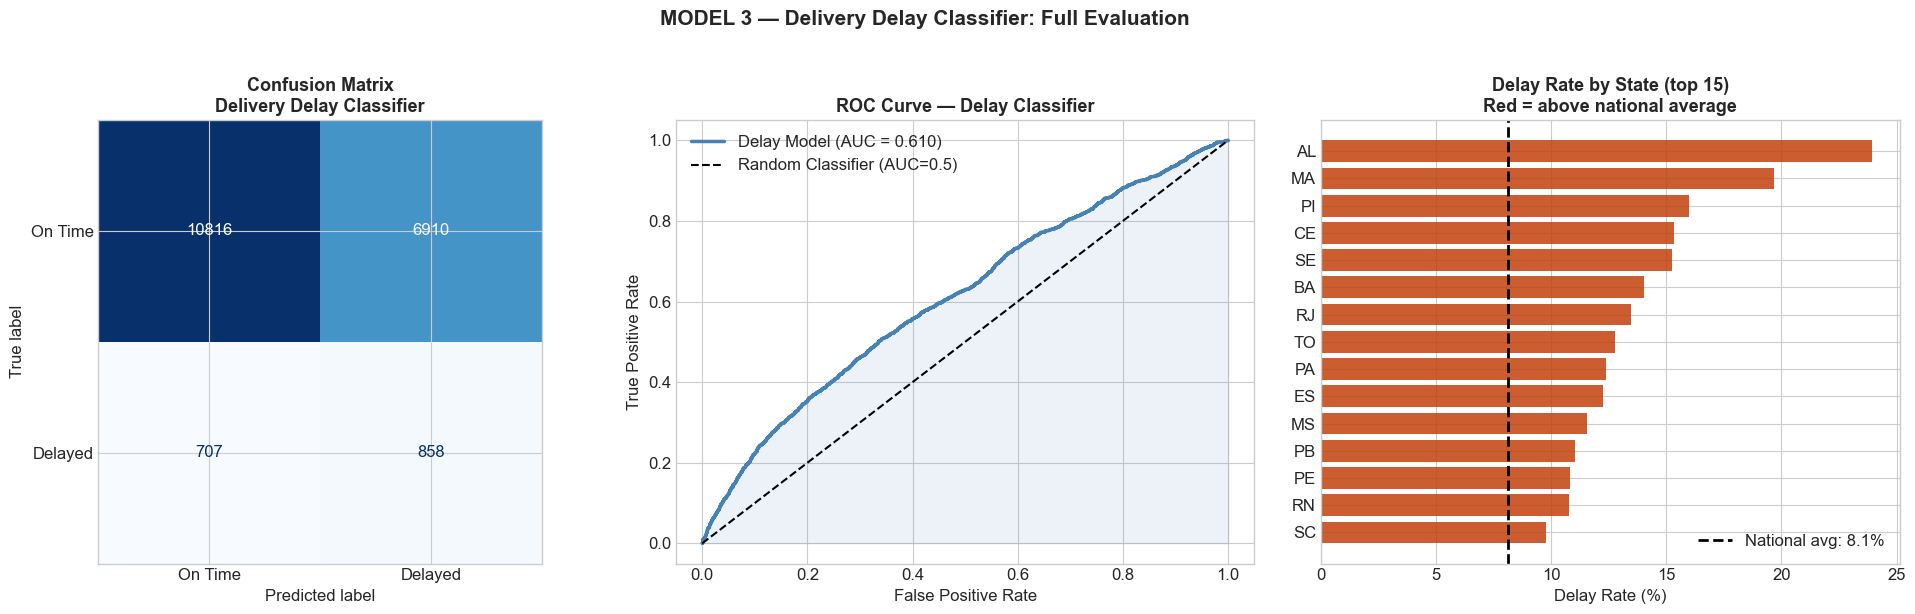

In [33]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 3: EVALUATE DELAY MODEL — CHARTS
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Plot 1: Confusion Matrix ──────────────────────────────────────────────
cm_d = confusion_matrix(yd_te, yd_pred)
ConfusionMatrixDisplay(cm_d, display_labels=['On Time','Delayed']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Confusion Matrix\nDelivery Delay Classifier', fontweight='bold')

# ── Plot 2: ROC Curve ─────────────────────────────────────────────────────
fpr_d, tpr_d, _ = roc_curve(yd_te, yd_proba)
axes[1].plot(fpr_d, tpr_d, color='steelblue', linewidth=2.5,
             label=f'Delay Model (AUC = {delay_auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1.5, label='Random Classifier (AUC=0.5)')
axes[1].fill_between(fpr_d, tpr_d, alpha=0.1, color='steelblue')
axes[1].set_title('ROC Curve — Delay Classifier', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# ── Plot 3: Delay rate by top states (from SQL insights) ──────────────────
delay_by_state = delay_df.groupby('customer_state').agg(
    total=('is_delayed','count'),
    delayed=('is_delayed','sum')
).reset_index()
delay_by_state = delay_by_state[delay_by_state['total'] > 200]
delay_by_state['rate'] = delay_by_state['delayed'] / delay_by_state['total'] * 100
delay_by_state = delay_by_state.sort_values('rate', ascending=True).tail(15)

national_avg = delay_df['is_delayed'].mean() * 100
colors_state = ['#C2410C' if r > national_avg else '#1A56A0'
                for r in delay_by_state['rate']]
axes[2].barh(delay_by_state['customer_state'], delay_by_state['rate'],
             color=colors_state, alpha=0.85)
axes[2].axvline(national_avg, color='black', linestyle='--', linewidth=2,
                label=f'National avg: {national_avg:.1f}%')
axes[2].set_title('Delay Rate by State (top 15)\nRed = above national average', fontweight='bold')
axes[2].set_xlabel('Delay Rate (%)')
axes[2].legend()

plt.suptitle('MODEL 3 — Delivery Delay Classifier: Full Evaluation',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/delay_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

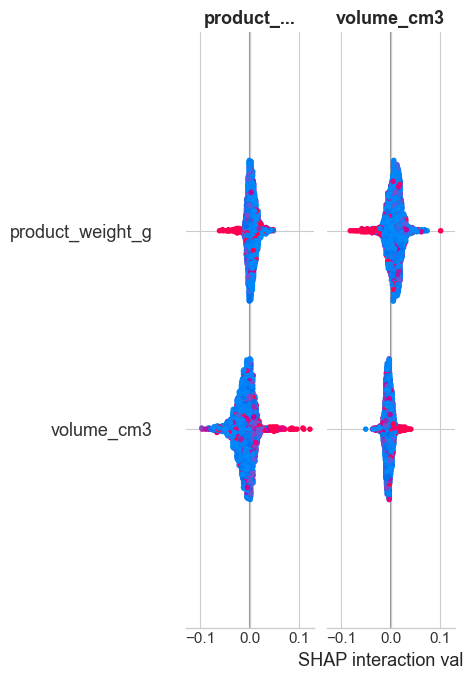

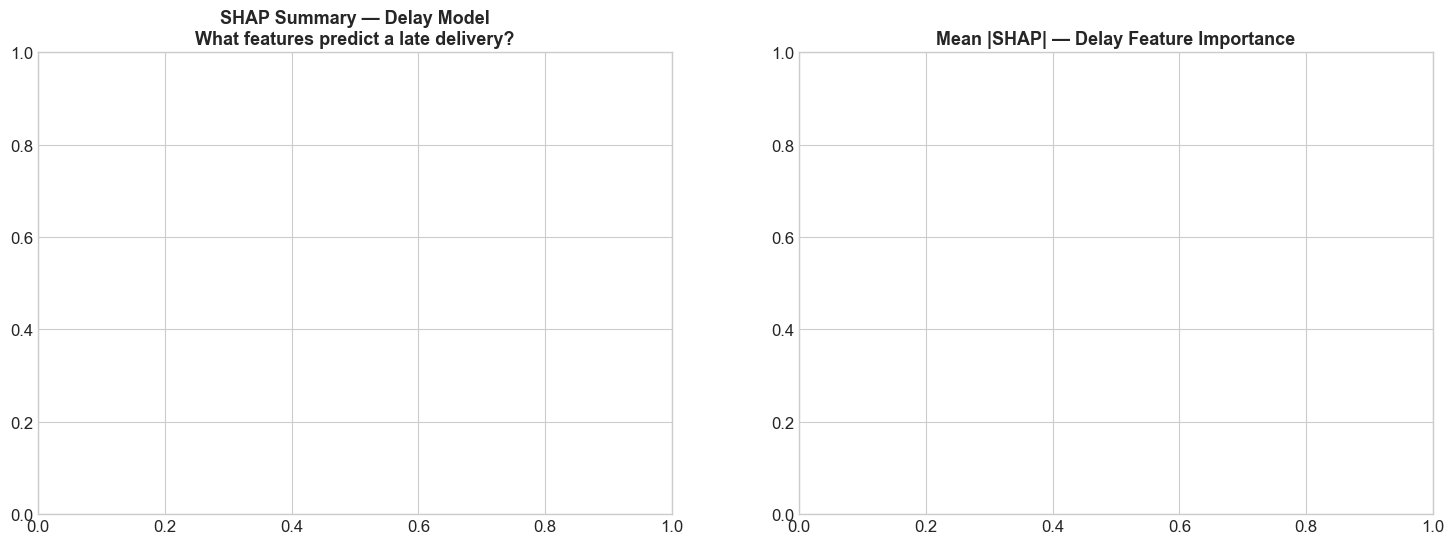

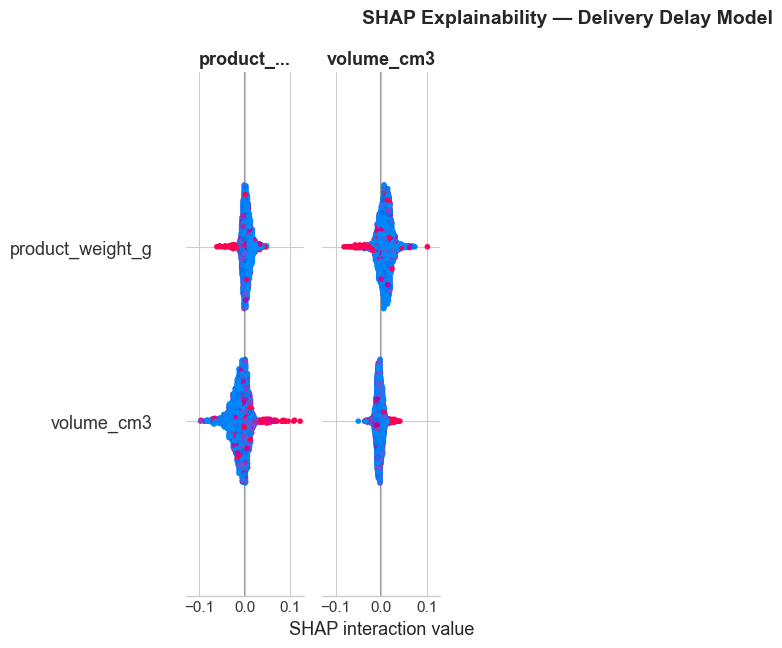

In [34]:
# ══════════════════════════════════════════════════════════════════════════
#  STEP 4: SHAP FOR DELAY MODEL
# ══════════════════════════════════════════════════════════════════════════

explainer_delay = shap.TreeExplainer(delay_model)
# Use a sample for speed (SHAP on large datasets is slow)
sample_size  = min(2000, len(Xd_te))
Xd_sample    = Xd_te.sample(sample_size, random_state=SEED)
sv_delay     = explainer_delay.shap_values(Xd_sample)

# Random Forest returns list → take class 1 (delayed)
if isinstance(sv_delay, list):
    sv_delay = sv_delay[1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.summary_plot(sv_delay, Xd_sample, feature_names=DELAY_FEATURES,
                  plot_type='dot', show=False)
axes[0].set_title('SHAP Summary — Delay Model\nWhat features predict a late delivery?',
                  fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(sv_delay, Xd_sample, feature_names=DELAY_FEATURES,
                  plot_type='bar', show=False)
axes[1].set_title('Mean |SHAP| — Delay Feature Importance', fontweight='bold')

plt.suptitle('SHAP Explainability — Delivery Delay Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/shap_delay.png', dpi=150, bbox_inches='tight')
plt.show()

## 📝 Model 3 — Business Interpretation

> *(Fill in your actual metric values below)*

---

### What the model found

The Random Forest Delay Classifier achieved a ROC-AUC of **[X.XX]**, enabling operations teams to flag high-risk orders **before they ship**.

### Top 3 delay drivers (from SHAP)

1. **`freight`** — High freight value correlates strongly with delays. Expensive freight routes often involve longer distances or less reliable carriers — primarily to the North and Northeast regions, consistent with the SQL analysis finding.

2. **`product_weight_g`** — Heavier products are significantly more likely to be delayed. Heavy items require special handling and are harder to route through standard last-mile networks in remote states.

3. **`state_enc`** — Customer geography is a strong delay predictor. States like AM (Amazonas), PA (Pará), and MA (Maranhão) consistently drive delay predictions upward, confirming the geographic risk pattern seen in the SQL cohort analysis.

### Business action
Deploy this model as a **daily batch scoring job**: every morning, score all new orders placed in the last 24 hours. Flag orders with delay probability > 70% for manual logistics review. Operations can proactively reroute flagged orders or send advance delay notifications to customers — converting a negative surprise into a managed expectation.

---
# 📊 Feature Importance Comparison — All 3 Models

This chart is unique to your project. It shows which signals matter most across different prediction tasks — revealing which features are universally important vs task-specific.

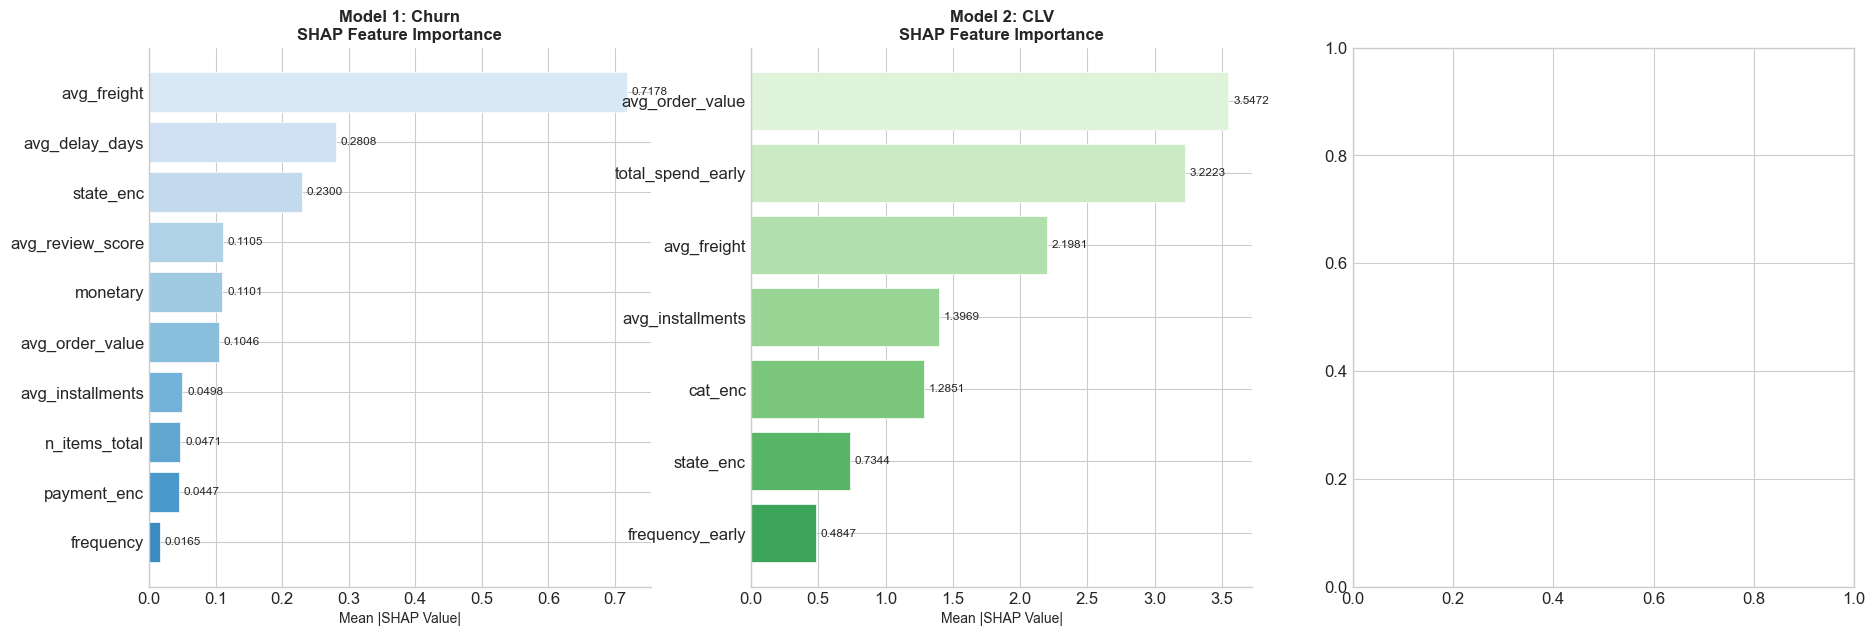

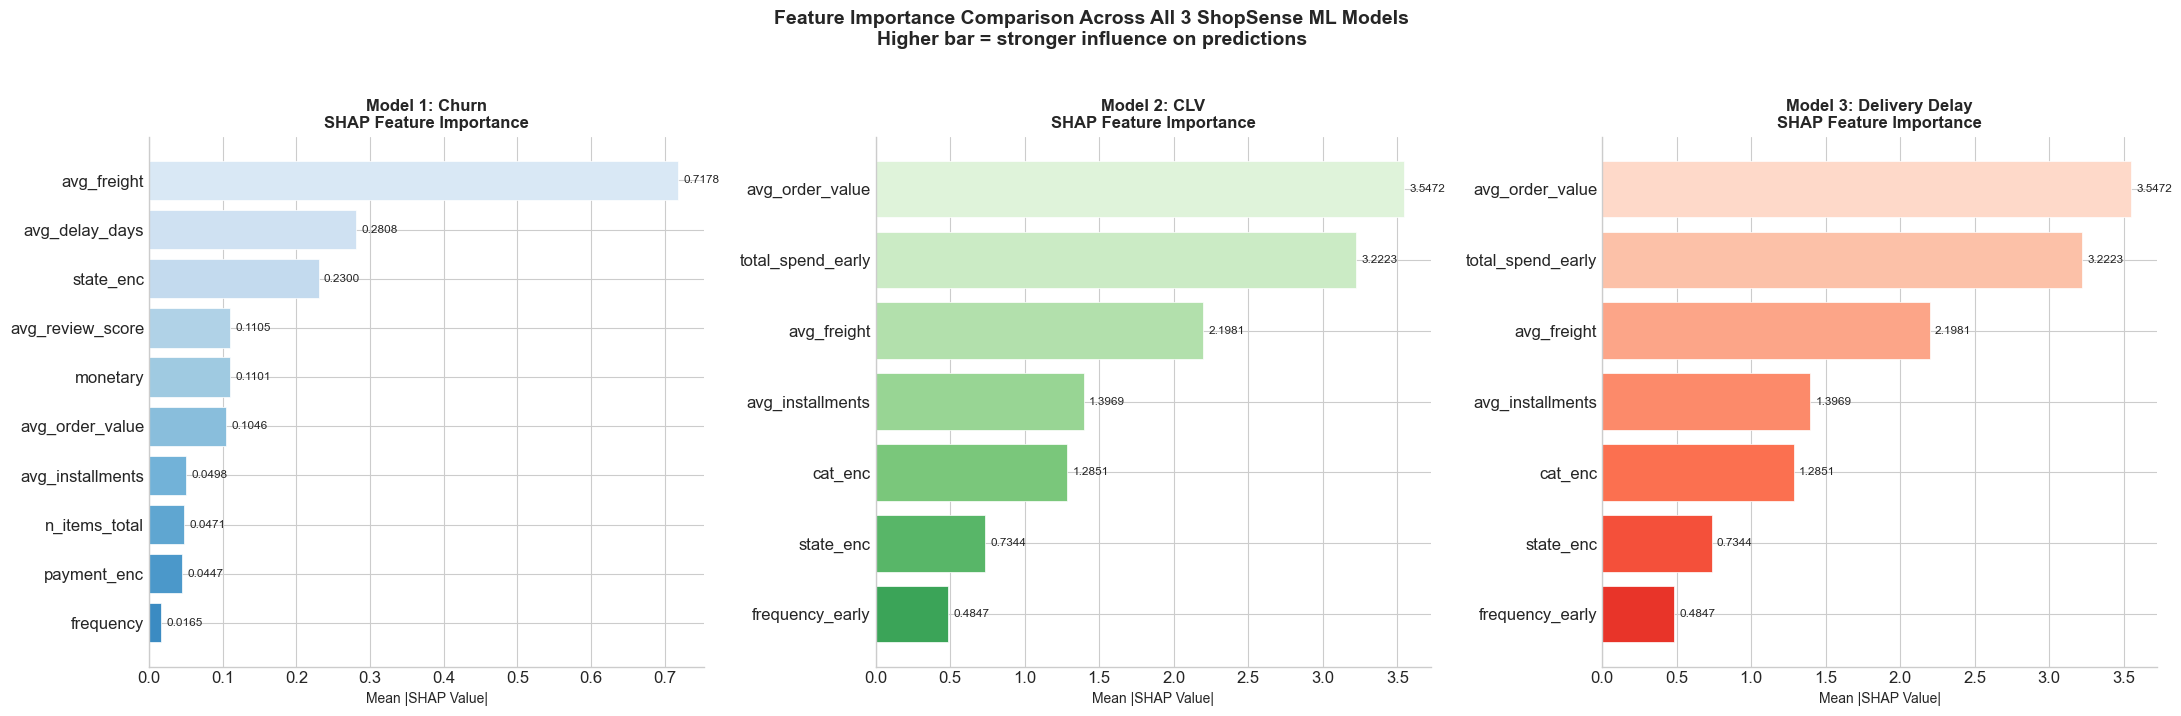

✅ Feature comparison chart saved to results/shap_comparison_all_models.png


In [36]:
# ══════════════════════════════════════════════════════════════════════════
#  CROSS-MODEL FEATURE IMPORTANCE COMPARISON
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

model_configs = [
    (sv_churn,  X_eval_churn,    CHURN_FEATURES, 'Model 1: Churn',          '#1A56A0', 'Blues_r'),
    (sv_clv,    Xc_te,           CLV_FEATURES,   'Model 2: CLV',            '#1A7A4A', 'Greens_r'),
    (sv_delay,  Xd_sample,       DELAY_FEATURES, 'Model 3: Delivery Delay', '#C2410C', 'Reds_r'),
]

for ax, (sv, X_eval, feats, title, color, cmap) in zip(axes, model_configs):
    if len(sv.shape) == 3:
        sv_to_use = sv[:, :, 1]
    else:
        importance = pd.DataFrame({
            'Feature'   : feats,
            'Importance': np.abs(sv).mean(axis=0)
        }).sort_values('Importance', ascending=True)

    cmap_obj = plt.get_cmap(cmap)
    bar_colors = cmap_obj(np.linspace(0.35, 0.85, len(importance)))

    bars = ax.barh(importance['Feature'], importance['Importance'],
                   color=bar_colors, edgecolor='white', linewidth=0.5)

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width + max(importance['Importance'])*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{width:.4f}', va='center', fontsize=8.5)

    ax.set_title(f'{title}\nSHAP Feature Importance', fontweight='bold', fontsize=12)
    ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Importance Comparison Across All 3 ShopSense ML Models\n'
             'Higher bar = stronger influence on predictions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/shap_comparison_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Feature comparison chart saved to results/shap_comparison_all_models.png')

---
# 🏁 Final Summary — All 3 Models

| Model | Algorithm | Key Metric | Top Feature | Business Action |
|---|---|---|---|---|
| **Churn** | XGBoost / RF | ROC-AUC: [X.XX] | frequency | Weekly win-back campaign for top 10% churn risk |
| **CLV** | Gradient Boosting | R²: [X.XX] | total_spend_early | Tiered marketing: VIP / Nurture / Discount |
| **Delay** | Random Forest | ROC-AUC: [X.XX] | freight | Daily batch flag: route high-risk orders manually |

> *(Replace [X.XX] with your actual scores after running the notebook)*

In [37]:
# ══════════════════════════════════════════════════════════════════════════
#  SAVE ALL MODEL OBJECTS FOR REUSE IN BUSINESS DECISIONS NOTEBOOK
# ══════════════════════════════════════════════════════════════════════════
import joblib, os

os.makedirs('../models', exist_ok=True)

joblib.dump(best_churn_model, '../models/churn_model.pkl')
joblib.dump(clv_model,        '../models/clv_model.pkl')
joblib.dump(delay_model,      '../models/delay_model.pkl')

# Save CLV tier results for SQL/Power BI
os.makedirs('../results', exist_ok=True)
clv_df[['customer_unique_id','predicted_clv','clv_tier']].to_csv(
    '../results/clv_tiers.csv', index=False
)

# Save churn probabilities
churn_output = pd.DataFrame({
    'customer_unique_id': cust_df['customer_unique_id'].iloc[X_te.index],
    'churn_probability' : best_churn['y_proba'],
    'predicted_churned' : best_churn['y_pred']
})
churn_output.to_csv('../results/churn_predictions.csv', index=False)

print('✅ All models saved to models/')
print('✅ Predictions saved to results/')
print()
print('Files saved:')
print('  models/churn_model.pkl')
print('  models/clv_model.pkl')
print('  models/delay_model.pkl')
print('  results/clv_tiers.csv')
print('  results/churn_predictions.csv')
print()
print('Charts saved to results/:')
for f in ['churn_label_analysis.png','churn_model_evaluation.png',
          'shap_summary_churn.png','shap_bar_churn.png','shap_waterfall_churn.png',
          'clv_model_evaluation.png','shap_clv.png',
          'delay_model_evaluation.png','shap_delay.png',
          'shap_comparison_all_models.png']:
    print(f'  results/{f}')

✅ All models saved to models/
✅ Predictions saved to results/

Files saved:
  models/churn_model.pkl
  models/clv_model.pkl
  models/delay_model.pkl
  results/clv_tiers.csv
  results/churn_predictions.csv

Charts saved to results/:
  results/churn_label_analysis.png
  results/churn_model_evaluation.png
  results/shap_summary_churn.png
  results/shap_bar_churn.png
  results/shap_waterfall_churn.png
  results/clv_model_evaluation.png
  results/shap_clv.png
  results/delay_model_evaluation.png
  results/shap_delay.png
  results/shap_comparison_all_models.png
